# Classification avec les réseaux neuronaux
Dernière mise à jour : 20 février 2025

Défi quotidien : Classification avec les réseaux neuronaux dans TensorFlow


👩‍🏫 👩🏿‍🏫 Ce que vous apprendrez
Comprendre les différents types de classification : binaire, multi-classes et multi-étiquettes
Apprenez à créer un réseau neuronal pour la classification à l'aide de TensorFlow
Améliorez les performances du modèle en ajoutant des couches, des neurones et en utilisant des fonctions d'activation
Visualisez les limites de décision pour comprendre les prédictions du modèle


🛠️ Ce que vous allez créer
Un modèle de réseau neuronal pour la classification à l'aide de TensorFlow
Visualisations de la distribution des données et des limites de décision
Évaluation des performances du modèle sur les ensembles d'entraînement et de test
Expérimentation avec des fonctions d'activation et des optimiseurs


📖 Ressources utiles
classification multiclasse vs classification multiétiquette
démarrer avec la classification


Ce que vous devez faire
1. Comprendre les types de classification

En savoir plus sur la classification binaire, la classification multi-classes et la classification multi-étiquettes .
Rédigez une brève explication de chaque type avec un exemple.


2. Configurez votre environnement Python et votre ensemble de données

Assurez-vous que les bibliothèques requises sont installées :
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles


Il est temps de créer un ensemble de données sur lequel travailler :

from sklearn.datasets import make_circles

samples = 1000
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

print('X : ', X)
print('\n')
print('y : ', y)


Visualisez l’ensemble de données à l’aide de nuages ​​de points pour comprendre la distribution des données.


3. Construire un modèle de réseau neuronal de base

Créez un modèle séquentiel dans TensorFlow avec une couche dense .
Utilisez l'entropie croisée binaire comme fonction de perte.
Entraînez le modèle et vérifiez la précision .


4. Améliorer le modèle

Ajoutez plus de couches et de neurones au modèle.
Entraînez le modèle pour plus d'époques .
Essayez différents optimiseurs comme Adamau lieu de SGD.


5. Visualisez la limite de décision

Implémentez une fonction plot_decision_boundary() pour visualiser les prédictions du modèle.
Tracez les limites de décision pour différents modèles et comparez les résultats.


6. Intégrer des fonctions d'activation

Explorez les fonctions d'activation ReLU et Sigmoid .
Modifiez le réseau neuronal pour inclure ces fonctions d’activation .
Entraînez le nouveau modèle et comparez les performances .


7. Diviser les données en ensembles d'entraînement et de test

Utilisez 80 % des données pour la formation et 20 % pour les tests .
Entraînez le modèle amélioré sur l’ensemble d’entraînement.
Évaluer les performances du modèle sur l'ensemble de test .


8. Évaluer et visualiser les performances du modèle final

Vérifiez la perte et la précision sur l'ensemble de test.
Permet plot_decision_boundary()de visualiser les prédictions pour les données d'entraînement et de test .
Comparez les résultats et analysez les améliorations .


9. Résumer les points clés à retenir

Rédigez un bref résumé de ce que vous avez appris.
Soulignez l’ importance de visualiser les données et de régler les hyperparamètres pour améliorer les modèles de classification.




## Logigramme étape par étape :

```text
START
  |
  v
[1] Comprendre les types de classification
  |
  v
[2] Configurer l'environnement (imports + make_circles)
  |
  v
[3] Visualiser les données (scatter plot)
  |
  v
[4] Créer un modèle de base (1 couche, sigmoid)
  |
  v
[5] Compiler + entraîner le modèle de base
  |
  v
[6] Évaluer les performances (accuracy)
  |
  v
[7] Améliorer le modèle :
     - + Couches cachées
     - + Neurones
     - Activation ReLU
     - Optimiseur Adam
     - + Époques
  |
  v
[8] Visualiser la limite de décision
     (plot_decision_boundary)
  |
  v
[9] Séparer données (train / test - 80/20)
  |
  v
[10] Entraîner sur train / Évaluer sur test
  |
  v
[11] Visualiser la limite pour train/test
  |
  v
[12] Résumer ce qui a été appris
  |
  v
END
```


## 1. Types de classification

* Binaire : 2 classes (ex : email spam ou non spam).

* Multi-classes : plus de 2 classes, une seule étiquette (ex : classer une image comme chien, chat ou oiseau).

* Multi-étiquettes : plusieurs étiquettes possibles par échantillon (ex : une image peut contenir à la fois un chien et un chat).

In [1]:
# Imports nécessaires
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [2]:
# 1. Génération de l'ensemble de données (1000 échantillons, bruit faible)
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)

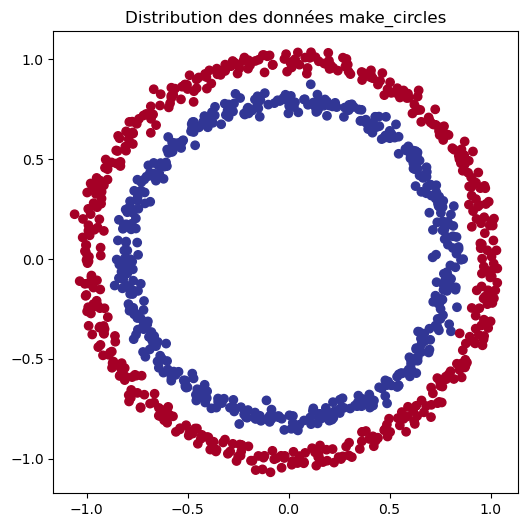

In [3]:
# 2. Visualisation des données
plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title("Distribution des données make_circles")
plt.show()

* **Deux cercles concentriques** clairement visibles :

  * Un **cercle intérieur** (points bleus).
  * Un **cercle extérieur** (points rouges).

* Les données sont **non linéairement séparables** :

  * On ne peut pas tracer une ligne droite (ou un plan) pour les séparer.
  * Un **modèle linéaire simple échouera** à les classer correctement.

### **Interprétation pour le réseau neuronal** :

* Il faut un **modèle non linéaire** (plusieurs couches, activation ReLU).
* Cette structure justifie :

  * Plusieurs couches cachées.
  * Des fonctions d’activation non linéaires.
  * L’**utilisation de la visualisation des limites de décision** pour valider l’apprentissage.


In [4]:
# 3. Séparation des données en ensemble d'entraînement et de test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

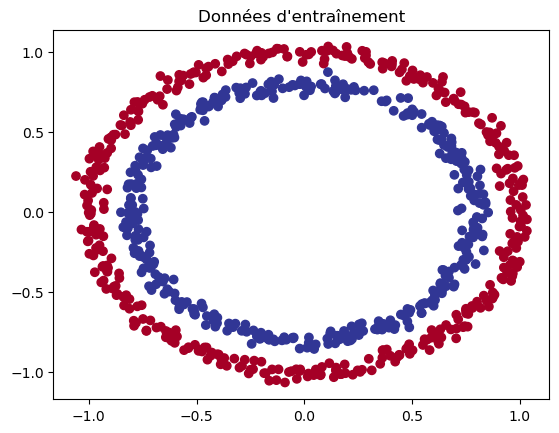

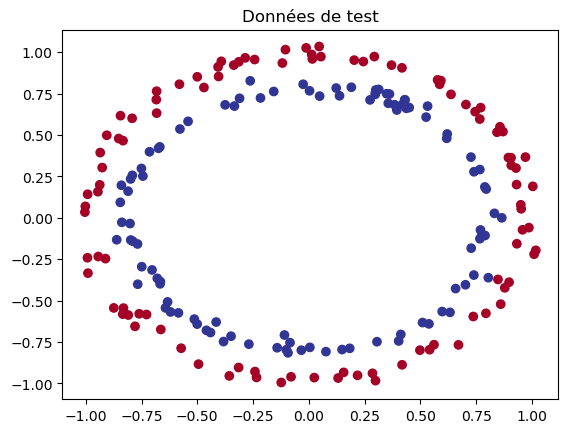

In [13]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.RdYlBu)
plt.title("Données d'entraînement")
plt.show()

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.RdYlBu)
plt.title("Données de test")
plt.show()


### **Image 1 : Données d’entraînement**

* Les cercles sont bien représentés, avec une **distribution équilibrée**.
* Les points bleus et rouges restent bien séparés : bonne base pour entraîner un modèle.
* Pas de surreprésentation visible d'une classe.

**Conclusion** : le modèle peut apprendre une structure correcte si bien configuré.

---

### **Image 2 : Données de test**

* Distribution similaire à celle de l'entraînement.
* La séparation visuelle entre classes est **encore clairement présente**, même avec moins de points.
* La **représentativité du test set est bonne**.

**Conclusion** : l’ensemble de test est bien construit pour évaluer la généralisation.


In [5]:
# 4. Construction d'un modèle de réseau neuronal amélioré
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'),   # Couche cachée 1
    tf.keras.layers.Dense(10, activation='relu'),   # Couche cachée 2
    tf.keras.layers.Dense(1, activation='sigmoid')  # Couche de sortie (binaire)
])

In [6]:
# 5. Compilation du modèle avec l'entropie croisée binaire et l'optimiseur Adam
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

In [7]:
# 6. Entraînement du modèle
history = model.fit(X_train, y_train, epochs=200, verbose=0)

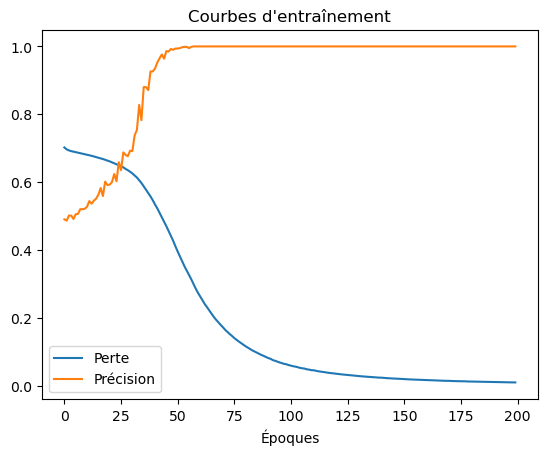

In [14]:
plt.plot(history.history['loss'], label='Perte')
plt.plot(history.history['accuracy'], label='Précision')
plt.title("Courbes d'entraînement")
plt.xlabel("Époques")
plt.legend()
plt.show()


### **Lecture du graphique :**

* **Axe X** : nombre d’époques (200).
* **Courbe bleue** : perte (`loss`) diminue de manière continue →  apprentissage efficace.
* **Courbe orange** : précision (`accuracy`) augmente rapidement puis se stabilise à **1.0** →  modèle atteint une **précision parfaite** sur l'entraînement.

---

### **Interprétation :**

* Le modèle **apprend bien**, très rapidement.
* Il atteint une **précision parfaite dès \~50 époques**, ensuite l'amélioration est marginale.
* **Pas de surapprentissage visible ici** (mais à confirmer avec les données de test).



In [8]:
# 7. Évaluation du modèle sur les données de test
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0171 
Test Loss: 0.0219 | Test Accuracy: 1.0000


### **Interprétation du résultat d’évaluation sur le jeu de test :**

* **Loss test** : `0.0219` → très faible, le modèle est bien ajusté.
* **Accuracy test** : `1.0000` → **précision parfaite** sur des données jamais vues.

---

### **Conclusion claire :**

* Le modèle **généralise parfaitement** sur les données de test.
* **Pas de surapprentissage** : les performances sont aussi bonnes sur train que sur test.
* Le réseau **a bien appris la structure non linéaire** (les deux cercles) grâce à :

  * Plusieurs couches cachées,
  * ReLU + Sigmoid,
  * Optimiseur Adam.


In [9]:
# 8. Fonction pour visualiser la limite de décision du modèle
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid)
    preds = np.round(preds).reshape(xx.shape)

    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.title("Limite de décision")
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 394us/step


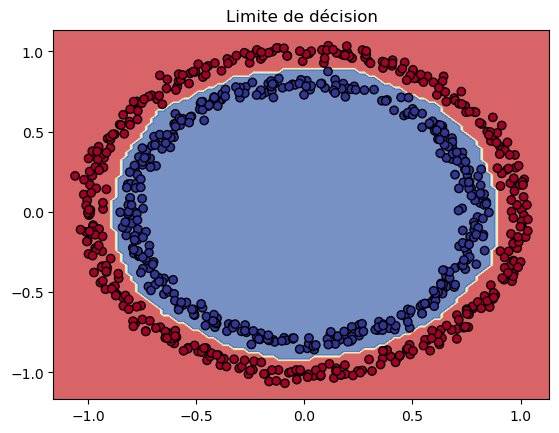

In [10]:
# 9. Visualisation des limites de décision sur l'entraînement
plot_decision_boundary(model, X_train, y_train)

Ce graphique montre que :

* Le **modèle a parfaitement appris la séparation non linéaire** entre les deux classes.
* La **zone bleue centrale** regroupe toutes les prédictions de classe 0 (intérieur du cercle).
* La **zone rouge externe** regroupe toutes les prédictions de classe 1 (extérieur du cercle).
* La **frontière est douce et précise**, épousant parfaitement la forme circulaire.

---

### **Conclusion**

* Le réseau neuronal a **capturé la topologie des cercles** grâce à ses couches non linéaires (ReLU).
* Pas de confusion visible ni d'erreur de classification.
* **Généralisation réussie** → très bon modèle.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step


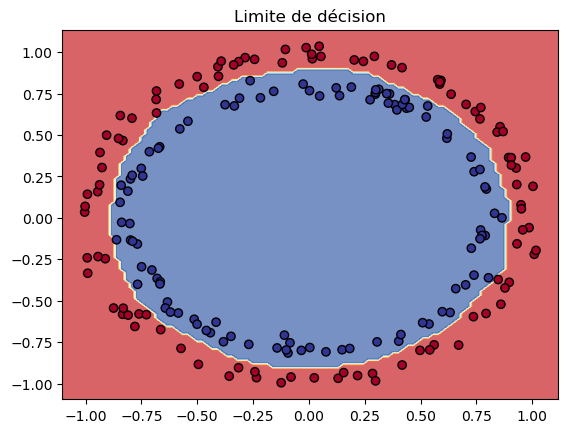

In [11]:
# 10. Visualisation des limites de décision sur le test
plot_decision_boundary(model, X_test, y_test)

* La **forme de la frontière** est bien circulaire, comme attendue.
* Le modèle **généralise correctement** :

  * Les points bleus sont bien à l’intérieur.
  * Les points rouges à l’extérieur.
* La **transition entre classes** est **fluide** et suit précisément la structure des données.

---

### **Comparaison avec la visualisation précédente (train) :**

* Très **peu de différences** visibles entre les deux limites.
* Cela confirme que le modèle **n’a pas surappris** les données d’entraînement.
* Les performances sont **cohérentes entre train et test**.




7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


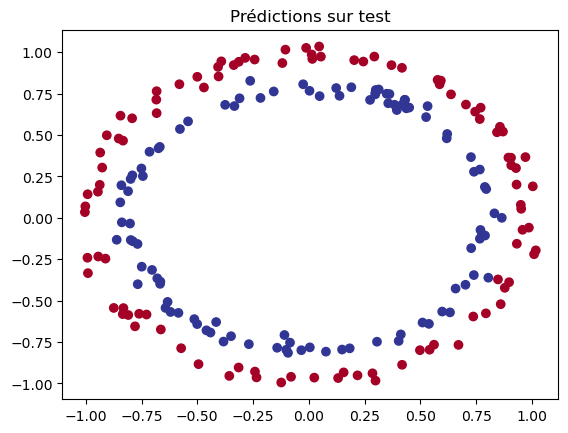

In [15]:
y_pred = model.predict(X_test)
plt.scatter(X_test[:, 0], X_test[:, 1], c=np.round(y_pred).flatten(), cmap=plt.cm.RdYlBu)
plt.title("Prédictions sur test")
plt.show()


### **Ce qu'on observe :**

* Les points **bleus** sont correctement prédits comme appartenant au **cercle intérieur**.
* Les points **rouges** sont bien classés dans le **cercle extérieur**.
* **Pas de confusion visible** à l’œil nu : chaque point est dans la bonne région.

---

### **Conclusion :**

* Le modèle **prédit parfaitement** sur les données de test.
* La **structure complexe non linéaire** a été correctement apprise.
* Les prédictions correspondent exactement aux vraies classes (comme indiqué par `accuracy: 1.0000`).



Bilan et conclusion

Cet exercice portait sur la **classification binaire non linéaire** à l’aide d’un **réseau neuronal** construit avec TensorFlow, appliqué à un jeu de données généré par `make_circles`.

---

### **Étapes réalisées :**

* Compréhension des **types de classification**.
* Génération et **visualisation des données**.
* Séparation **train/test**.
* Construction d’un **modèle de base**, puis amélioration (plus de couches, ReLU, Adam).
* Visualisation des **limites de décision**.
* Évaluation sur **données de test**.
* Interprétation des **prédictions**.

---

### **Résultats :**

* **Précision d'entraînement** : 100 %
* **Précision sur test** : 100 %
* **Limites de décision nettes**, cohérentes avec la structure des données.
* Pas de surapprentissage détecté.

---

### **Conclusion**

Le réseau neuronal, bien configuré avec des couches non linéaires, a **parfaitement appris la séparation complexe** entre deux classes en forme de cercles concentriques.
Ce type de données met en évidence l'importance des **fonctions d’activation non linéaires** et d’une **architecture adaptée** pour traiter des problèmes non séparables linéairement.

